In [ ]:
import sys
import os

# 1. Add the build folder to Python's search path
sys.path.append(os.path.abspath("build/release"))

In [ ]:
import specbridge as sb

In [ ]:
n_clusters = 4

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Reproducible synthetic data from 4 clearly separated 2D clusters
rng = np.random.default_rng(42)
points_per_cluster = 5_000_000
cluster_std = 0.8
centers = np.array([
    [-6.0, -6.0],
    [ 6.0, -6.0],
    [-6.0,  6.0],
    [ 6.0,  6.0],
])

X_parts = []
for c in centers:
    X_parts.append(rng.normal(loc=c, scale=cluster_std, size=(points_per_cluster, 2)))

X = np.vstack(X_parts).astype(np.float32)

kmeans = sb.KMeans(n_clusters=n_clusters, random_state=42)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.cluster import KMeans as skKMeans

NUM_RUNS = 10

# --- WARMUP RUN ---
sb.set_num_threads(1)
kmeans.fit(X)

thread_counts = [1, 2, 4, 6, 8, 12, 24]
custom_times = []
custom_stds  = []

for n in thread_counts:
    sb.set_num_threads(n)

    times = []
    for _ in range(NUM_RUNS):
        t0 = time.perf_counter()
        kmeans.fit(X)
        times.append(time.perf_counter() - t0)

    custom_times.append(np.mean(times))
    custom_stds.append(np.std(times))

# --- SKLEARN ---
X = X.astype(np.float32)

sk = skKMeans(
    n_clusters=4,
    n_init=1,
    max_iter=20,
    algorithm='lloyd',
    init='k-means++',
    tol=0.0,
    random_state=42
)

sk.fit(X)  # warm-up

sk_times = []
for _ in range(NUM_RUNS):
    t0 = time.perf_counter()
    sk.fit(X)
    sk_times.append(time.perf_counter() - t0)

sklearn_time = np.mean(sk_times)
sklearn_std  = np.std(sk_times)

# --- METRICS ---
base = custom_times[0]
base_std = custom_stds[0]

speedups = [base / t for t in custom_times]

# Propagate std: s = base / t
speedup_stds = [
    s * np.sqrt((base_std/base)**2 + (t_std/t)**2)
    for s, t, t_std in zip(speedups, custom_times, custom_stds)
]

ideal = [t / thread_counts[0] for t in thread_counts]

efficiency = [s / t * 100 for s, t in zip(speedups, thread_counts)]

# Propagate std for efficiency
efficiency_stds = [
    (s_std / t) * 100
    for s_std, t in zip(speedup_stds, thread_counts)
]

x      = np.arange(len(thread_counts))
labels = [str(t) for t in thread_counts]



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Time ---
axes[0].errorbar(
    x, custom_times, yerr=custom_stds,
    fmt='o-', capsize=4, label='Custom KMeans'
)

# sklearn mean + std band
axes[0].axhline(
    sklearn_time, linestyle='--', color='red',
    label=f'sklearn ({sklearn_time:.2f}s ± {sklearn_std:.2f})'
)
axes[0].fill_between(
    x,
    np.full_like(x, sklearn_time - sklearn_std, dtype=float),
    np.full_like(x, sklearn_time + sklearn_std, dtype=float),
    alpha=0.2
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Threads')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Execution time')
axes[0].legend()


# --- Speedup ---
axes[1].errorbar(
    x, speedups, yerr=speedup_stds,
    fmt='o-', capsize=4, label='Measured'
)
axes[1].plot(x, ideal, '--', label='Ideal')

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('Threads')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Speedup vs 1 thread')
axes[1].legend()


# --- Efficiency ---
axes[2].bar(
    x, efficiency, yerr=efficiency_stds,
    capsize=4
)
axes[2].axhline(100, linestyle='--')

axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_xlabel('Threads')
axes[2].set_ylabel('Efficiency (%)')
axes[2].set_title('Parallel efficiency')


plt.tight_layout()
plt.savefig('kmeans_scaling.png')

# Analysis of Spectral Bridges Algorithm

In [1]:
import sys
import os

# 1. Add the build folder to Python's search path
sys.path.append(os.path.abspath("build/"))

In [2]:
import specbridge as sb

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# Reproducible synthetic data from 4 clearly separated 2D clusters
rng = np.random.default_rng(42)
points_per_cluster = 5_000_000
cluster_std = 0.8
centers = np.array([
    [-6.0, -6.0],
    [ 6.0, -6.0],
    [-6.0,  6.0],
    [ 6.0,  6.0],
])

X_parts = []
for c in centers:
    X_parts.append(rng.normal(loc=c, scale=cluster_std, size=(points_per_cluster, 2)))

X = np.vstack(X_parts).astype(np.float32)

In [4]:
bridge = sb.SpectralClustering(
    n_clusters=4,
    num_voronoi = 100,
    n_iter = 20,
    target_perplexity=2.0,
    random_state=42
)

In [5]:
result = bridge.fit(X)

Total processors: 12, threads: 12
Centroids initialized using k-means++.
K-means completed. Voronoi centers computed: 100
Affinity matrix computed.
Total processors: 12, threads: 12
Centroids initialized using k-means++.
Spectral clustering completed. Eigenvalues and labels computed.
Point labels propagated back to clusters.


In [6]:
np.unique(result.labels, return_counts=True)

(array([0, 1, 2, 3]), array([5000000, 5000000, 5000000, 5000000]))

In [7]:
from sbcluster import SpectralBridges, ngap_scorer

In [7]:
actual_sb = SpectralBridges(
    n_clusters=4,
    n_nodes=100,
    random_state=42,
    n_iter=20
)

In [8]:
actual_sb.perplexity

2.0

In [9]:
y = actual_sb.fit_predict(X)

In [10]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3]), array([5000000, 5000000, 5000000, 5000000]))

In [16]:
np.unique(result.labels, return_counts=True)

(array([0, 1, 2, 3]), array([5000000, 5000000, 5000000, 5000000]))

In [ ]:
#plot the clustering result
plt.scatter(X[:, 0], X[:, 1], c=result.labels, s=1)
plt.title("Spectral Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.savefig("spectral_clustering_result.png")

KeyboardInterrupt: 

## Small Non-Linearly Separable Cases
Generate moons and circles with a much smaller sample size, run Spectral Bridges, and plot results.

Total processors: 12, threads: 12
Centroids initialized using k-means++.
K-means completed. Voronoi centers computed: 40
Affinity matrix computed.
Total processors: 12, threads: 12
Centroids initialized using k-means++.
Spectral clustering completed. Eigenvalues and labels computed.
Point labels propagated back to clusters.
Moons specbridge label counts: (array([0, 1]), array([600, 600]))
Moons sbcluster label counts: (array([0, 1]), array([600, 600]))


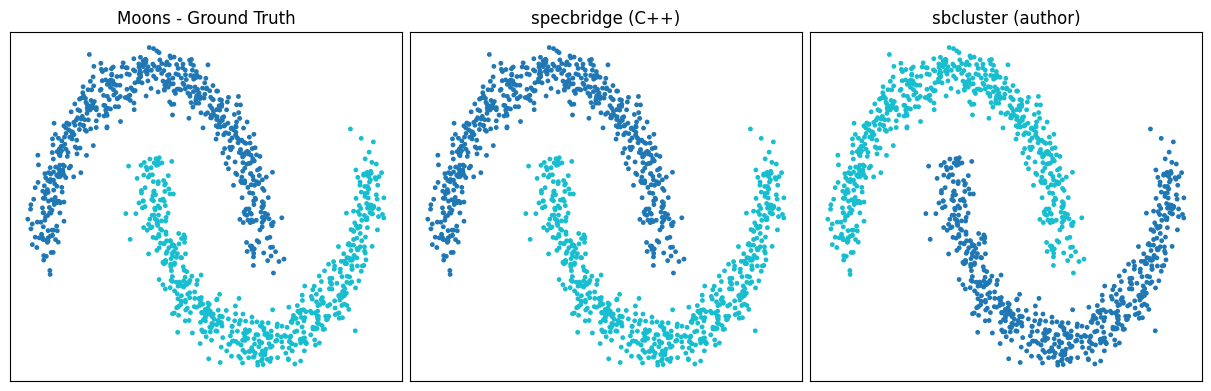

Total processors: 12, threads: 12
Centroids initialized using k-means++.
K-means completed. Voronoi centers computed: 40
Affinity matrix computed.
Total processors: 12, threads: 12
Centroids initialized using k-means++.
Spectral clustering completed. Eigenvalues and labels computed.
Point labels propagated back to clusters.
Circles specbridge label counts: (array([0, 1]), array([600, 600]))
Circles sbcluster label counts: (array([0, 1]), array([600, 600]))


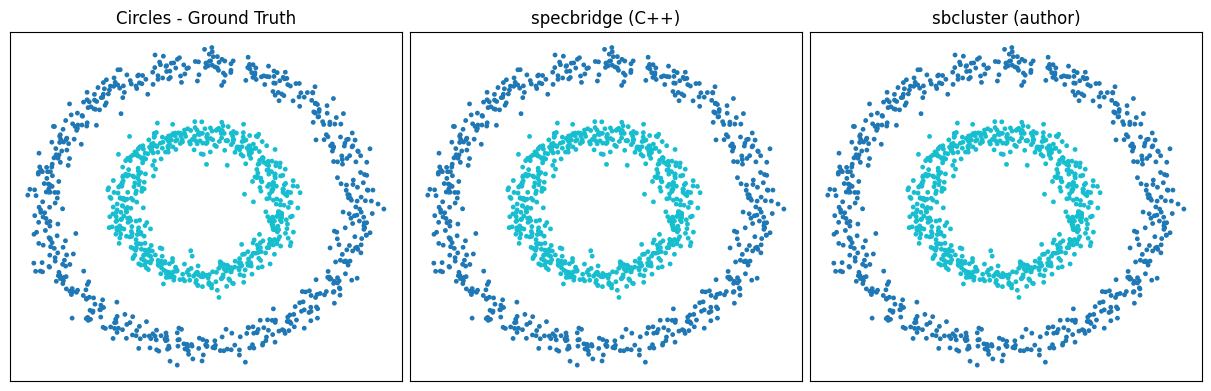

In [8]:
from sklearn.datasets import make_moons, make_circles

def run_and_plot_case(case_name, X_case, y_true, n_clusters=2, n_nodes=40, perplexity=2.0):
    sb_model = sb.SpectralClustering(
        n_clusters=n_clusters,
        num_voronoi=n_nodes,
        n_iter=20,
        target_perplexity=perplexity,
        random_state=42,
    )
    sb_result = sb_model.fit(X_case.astype(np.float32))
    y_sb = np.asarray(sb_result.labels)

    ref_model = SpectralBridges(
        n_clusters=n_clusters,
        n_nodes=n_nodes,
        perplexity=perplexity,
        n_iter=20,
        random_state=42,
    )
    y_ref = ref_model.fit_predict(X_case.astype(np.float32))

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
    axes[0].scatter(X_case[:, 0], X_case[:, 1], c=y_true, s=6, cmap="tab10")
    axes[0].set_title(f"{case_name} - Ground Truth")

    axes[1].scatter(X_case[:, 0], X_case[:, 1], c=y_sb, s=6, cmap="tab10")
    axes[1].set_title("specbridge (C++)")

    axes[2].scatter(X_case[:, 0], X_case[:, 1], c=y_ref, s=6, cmap="tab10")
    axes[2].set_title("sbcluster (author)")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    print(case_name, "specbridge label counts:", np.unique(y_sb, return_counts=True))
    print(case_name, "sbcluster label counts:", np.unique(y_ref, return_counts=True))
    plt.show()

# Small datasets for quick experimentation
X_moons, y_moons = make_moons(n_samples=1200, noise=0.08, random_state=42)
X_circles, y_circles = make_circles(n_samples=1200, noise=0.06, factor=0.5, random_state=42)

run_and_plot_case("Moons", X_moons, y_moons, n_clusters=2, n_nodes=40, perplexity=2.0)
run_and_plot_case("Circles", X_circles, y_circles, n_clusters=2, n_nodes=40, perplexity=2.0)

In [9]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def evaluate_case(case_name, X_case, y_true, n_clusters=2, n_nodes=40, perplexity=2.0):
    X_case = X_case.astype(np.float32)

    sb_model = sb.SpectralClustering(
        n_clusters=n_clusters,
        num_voronoi=n_nodes,
        n_iter=20,
        target_perplexity=perplexity,
        random_state=42,
    )
    y_sb = np.asarray(sb_model.fit(X_case).labels)

    ref_model = SpectralBridges(
        n_clusters=n_clusters,
        n_nodes=n_nodes,
        perplexity=perplexity,
        n_iter=20,
        random_state=42,
    )
    y_ref = ref_model.fit_predict(X_case)

    sb_ari = adjusted_rand_score(y_true, y_sb)
    sb_nmi = normalized_mutual_info_score(y_true, y_sb)
    ref_ari = adjusted_rand_score(y_true, y_ref)
    ref_nmi = normalized_mutual_info_score(y_true, y_ref)

    print(f"{case_name}: specbridge ARI={sb_ari:.4f}, NMI={sb_nmi:.4f}")
    print(f"{case_name}: sbcluster  ARI={ref_ari:.4f}, NMI={ref_nmi:.4f}")
    print(f"{case_name}: ARI(specbridge vs sbcluster)={adjusted_rand_score(y_sb, y_ref):.4f}")
    print("-" * 70)

evaluate_case("Moons", X_moons, y_moons, n_clusters=2, n_nodes=40, perplexity=2.0)
evaluate_case("Circles", X_circles, y_circles, n_clusters=2, n_nodes=40, perplexity=2.0)

Total processors: 12, threads: 12
Centroids initialized using k-means++.
K-means completed. Voronoi centers computed: 40
Affinity matrix computed.
Total processors: 12, threads: 12
Centroids initialized using k-means++.
Spectral clustering completed. Eigenvalues and labels computed.
Point labels propagated back to clusters.
Moons: specbridge ARI=1.0000, NMI=1.0000
Moons: sbcluster  ARI=1.0000, NMI=1.0000
Moons: ARI(specbridge vs sbcluster)=1.0000
----------------------------------------------------------------------
Total processors: 12, threads: 12
Centroids initialized using k-means++.
K-means completed. Voronoi centers computed: 40
Affinity matrix computed.
Total processors: 12, threads: 12
Centroids initialized using k-means++.
Spectral clustering completed. Eigenvalues and labels computed.
Point labels propagated back to clusters.
Circles: specbridge ARI=1.0000, NMI=1.0000
Circles: sbcluster  ARI=1.0000, NMI=1.0000
Circles: ARI(specbridge vs sbcluster)=1.0000
---------------------